# Fifith Stage: Machine Learning

## 5.2 Data Process

<div style='text-align: justify'>With the datasets representing features and classes defined, a machine learning algorithm will be applied to determine which enzymes contribute most to class discrimination. For this purpose, a Random Forest classifier will be used. Given the structure of the dataset, two considerations must be taken into account:</div>
<ol>
    <li>The dataset is highly unbalanced. As noted previously, class 1 contains 146 combinations, whereas class 0 contains 999.854 combinations; thus, only 0.0146% of the data belongs to the class of interest. To address this imbalance, a RandomizedSearchCV procedure is performed to evaluate whether SMOTE improves model recall. If the hyperparameter optimization indicates that SMOTE enhances recall, it will be applied; otherwise, it will be excluded. Additionally, the class_weight parameter of the Random Forest classifier is tested as an alternative strategy to handle class imbalance. If neither approach improves recall, no class balancing method will be used. The primary objective throughout this process is to maximize recall. </li><br>
    <li>In this case, minimizing false negatives is critical, since the positive cases correspond to the combinations of interest in the analysis. Therefore, model configuration will prioritize the <b>optimization of recall</b>, even if this results in lower precision in other scenarios.</li>
</ol>
<div style='text-align: justify'>Taking these considerations into account, we proceed with the model configuration.</div>

In [1]:
# For visualization of the results
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# For model creation and visualization
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE

# For data manipulation
import pandas as pd
import numpy as np

In [2]:
# Loading the flux combinations
df_X = pd.read_csv('Datasets/features.csv')

In [3]:
df_X

,PDH_fw,PPC_fw,CS_fw,ACONTa_fw,ACONTa_bw,ACONTb_fw,ACONTb_bw,ICDHyr_fw,ICDHyr_bw,AKGDH_fw,SUCOAS_fw,SUCOAS_bw,FUM_fw,FUM_bw,FRD2_fw,ICL_fw,ICL_bw,MALS_fw
0,0.173741,0.381363,0.273401,1.252237,0.978835,0.815568,0.542166,0.294749,0.283189,0.000000,0.000000,0.000000,0.000000,0.369804,0.369804,1.161967,0.900125,0.261842
1,0.000000,3.237578,0.229919,2.535450,2.305531,1.725970,1.496051,1.362675,1.132756,0.000000,0.985846,0.950869,1.100465,1.479215,0.448039,1.161967,1.161967,0.000000
2,0.173741,2.504546,0.261842,2.020747,1.758905,2.430507,2.168665,0.099471,0.099471,0.000000,0.492923,0.492923,0.370528,2.875074,2.504546,2.198454,1.936612,0.261842
3,0.521223,1.074011,0.000000,1.252237,1.252237,0.641637,0.641637,0.382660,0.382660,0.000000,2.437544,2.437544,0.741057,1.815067,1.074011,1.161967,1.161967,0.000000
4,1.563670,1.038482,0.483726,1.252237,0.768510,3.736724,3.252998,1.232227,1.168125,0.000000,0.031402,0.000000,0.000000,0.000000,0.062208,1.968913,1.549290,0.419624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.521223,0.656696,0.360367,1.636492,1.276125,0.360367,0.000000,1.515416,1.515416,0.000000,1.971692,1.971692,1.111585,1.768281,0.656696,3.071623,2.711257,0.360367
999996,1.563670,2.871062,0.361313,0.867981,0.506668,0.361313,0.000000,0.665849,0.566378,0.099471,3.943385,4.042856,0.000000,0.207693,0.207693,1.423809,1.161967,0.261842
999997,0.521223,0.305451,0.360367,2.789257,2.428891,1.444699,1.084333,2.480412,2.265513,0.000000,0.000000,0.000000,1.018860,1.109411,0.090552,2.082080,1.936612,0.145468
999998,1.216188,0.865354,0.145468,0.867981,0.722514,4.436801,4.291333,0.382660,0.382660,0.000000,3.412562,3.412562,0.000000,0.865354,0.865354,1.694757,1.549290,0.145468


In [4]:
# Considering the range of flux values, the data are normalized using min–max normalization.
df_X = (df_X - df_X.min()) / (df_X.max() - df_X.min())

In [5]:
df_X

,PDH_fw,PPC_fw,CS_fw,ACONTa_fw,ACONTa_bw,ACONTb_fw,ACONTb_bw,ICDHyr_fw,ICDHyr_bw,AKGDH_fw,SUCOAS_fw,SUCOAS_bw,FUM_fw,FUM_bw,FRD2_fw,ICL_fw,ICL_bw,MALS_fw
0,0.111111,0.017856,0.083654,0.261998,0.275126,0.137837,0.108891,0.079971,0.106938,0.000000,0.000000,0.000000,0.000000,0.075890,0.111111,0.295423,0.258219,0.107040
1,0.000000,0.689691,0.070350,0.530477,0.648027,0.291703,0.300474,0.369722,0.427750,0.000000,0.222222,0.211020,0.329999,0.303562,0.134618,0.295423,0.333333,0.000000
2,0.111111,0.517268,0.080117,0.422789,0.494384,0.410775,0.435565,0.026989,0.037562,0.000000,0.111111,0.109391,0.111111,0.590017,0.752515,0.558943,0.555556,0.107040
3,0.333333,0.180780,0.000000,0.261998,0.351973,0.108442,0.128870,0.103824,0.144500,0.000000,0.549453,0.540949,0.222222,0.372485,0.322697,0.295423,0.333333,0.000000
4,1.000000,0.172423,0.148008,0.261998,0.216009,0.631536,0.653348,0.334329,0.441106,0.000000,0.007078,0.000000,0.000000,0.000000,0.018691,0.500584,0.444444,0.171541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.333333,0.082620,0.110263,0.342393,0.358687,0.060905,0.000000,0.411164,0.572250,0.000000,0.444444,0.437565,0.333333,0.362883,0.197311,0.780941,0.777778,0.147317
999996,1.000000,0.603480,0.110553,0.181602,0.142412,0.061065,0.000000,0.180659,0.213875,0.049225,0.888889,0.897205,0.000000,0.042622,0.062403,0.361995,0.333333,0.107040
999997,0.333333,0.000000,0.110263,0.583579,0.682701,0.244166,0.217783,0.672987,0.855500,0.000000,0.000000,0.000000,0.305528,0.227671,0.027207,0.529356,0.555556,0.059467
999998,0.777778,0.131700,0.044510,0.181602,0.203081,0.749855,0.861892,0.103824,0.144500,0.000000,0.769235,0.757328,0.000000,0.177586,0.260004,0.430881,0.444444,0.059467


In [6]:
# Loading the classes
df_y = pd.read_csv('../Datasets/targets_final.csv')

In [7]:
# Removing the NADH production and biomass columns, retaining only the class labels.
df_y = df_y.iloc[:,2]

In [8]:
df_y

0         0
1         0
2         0
3         0
4         0
         ..
999995    0
999996    0
999997    0
999998    0
999999    0
Name: Classes, Length: 1000000, dtype: int64

## 5.2.1 Model Calibration

In [9]:
# Preparation for the RandomizedSearchCV algorithm.
from imblearn.pipeline import Pipeline

# To averiguate if smote are the best option for model's calibration
pipeline = Pipeline([
    ('smote', 'passthrough'),
    ('rf', RandomForestClassifier(random_state=42,verbose=1))
])

# The set of parameters that will be tested
param_dist = {
    'rf__n_estimators': [100, 200, 300, 500],            
    'rf__max_depth': [5, 8, 10, 20, None],               
    'rf__min_samples_split': [2, 5, 10, 20],
    'rf__min_samples_leaf': [1, 2, 4, 5, 10],
    'rf__max_features': ['sqrt', 'log2', 0.2, 0.5],      
    'rf__criterion': ['gini', 'entropy'],
    'rf__bootstrap': [True, False],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample'],
    'smote':['passthrough',SMOTE(sampling_strategy=0.01, random_state=42)],
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42) 

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=6,  
    scoring='recall', 
    cv=cv,
    verbose=2,
    n_jobs=-1
)

search.fit(df_X, df_y)

print("Best parameters for recall:", search.best_params_)
print("Best recall:", search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   48.7s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   49.8s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   50.6s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   51.8s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   56.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   56.9s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Do

[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 4.2min


[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    3.6s finished
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  9.3min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s


[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 4.4min
[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 4.4min


[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    3.6s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.4min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.5min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.5min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished


[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 4.6min


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.6min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=gini, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=200, smote=passthrough; total time= 4.6min
[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=gini, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=200, smote=passthrough; total time= 4.6min


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.7min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.7min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.8min finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  9.8min finished
[Parallel(n_j

[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 4.9min
[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=gini, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=200, smote=passthrough; total time= 4.9min


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed: 10.0min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed: 10.1min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_j

[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 5.3min


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.8s finished


[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=gini, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=200, smote=passthrough; total time= 5.3min


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed: 10.3min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s


[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 5.4min


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.9s finished


[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=gini, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=200, smote=passthrough; total time= 5.4min
[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 5.5min
[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=10, rf__max_features=0.2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 5.5min
[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strat

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min


[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 6.6min
[CV] END rf__bootstrap=False, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=200, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 6.7min
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=20, rf__n_estimators=500, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 8.1min
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__criterion=entropy, rf__max_depth=5, rf__max_features=log2, rf__min_samples_leaf=4, rf__min_samples_split=20, rf__n_estimators=500, smote=SMOTE(ran

[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  4.3min


Best parameters for recall: {'smote': SMOTE(random_state=42, sampling_strategy=0.01), 'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': 5, 'rf__criterion': 'entropy', 'rf__class_weight': 'balanced', 'rf__bootstrap': False}
Best recall: 0.7194252873563218


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  4.3min finished


[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=entropy, rf__max_depth=8, rf__max_features=0.5, rf__min_samples_leaf=1, rf__min_samples_split=20, rf__n_estimators=300, smote=passthrough; total time= 9.7min
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=entropy, rf__max_depth=5, rf__max_features=0.5, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 9.8min
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=entropy, rf__max_depth=8, rf__max_features=0.5, rf__min_samples_leaf=1, rf__min_samples_split=20, rf__n_estimators=300, smote=passthrough; total time= 9.8min
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=entropy, rf__max_depth=5, rf__max_features=0.5, rf__min_samples_leaf=2, rf__min_samples_split=2, rf__n_estimators=300, smote=SMOTE(random_state=42, sampling_strategy=0.01); total time= 9.9min
[CV] END rf__bootstrap=True, rf__cla

<div style='text-align: justify'><b>As indicated, the best parameters identified for the model are:</b></div>
<ol>
    <li><b>smote:</b> SMOTE(random_state=42, sampling_strategy=0.01);</li>
    <li><b>n_estimators:</b> 200;</li>
    <li><b>min_samples_split:</b> 10;</li>
    <li><b>min_samples_leaf:</b> 4;</li>
    <li><b>max_features:</b> log2;</li>
    <li><b>max_depth:</b> 5;</li>
    <li><b>criterion:</b> entropy;</li>
    <li><b>class_weight:</b> balanced;</li>
    <li><b>bootstrap:</b> False.</li>
</ol>

<div style='text-align: justify'>It can also be observed that, with the specified parameters, the model achieved a maximum recall of <b>0.72</b>, which is a strong result given the characteristics of the dataset.</div><br>

## 5.2.2 Model Creation

<div style='text-align: justify'>Now, with the optimal parameters determined for maximizing recall, the model can be constructed as follows:</div>

In [10]:
# Determination of train and test datasets
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size = 0.2, random_state = 42, stratify=df_y) 

# SMOTE
sm = SMOTE(sampling_strategy = 0.01, random_state=42)
X_train, y_train = sm.fit_resample(X_train,y_train)

# Model creation
clf = RandomForestClassifier(n_estimators=200, 
                             min_samples_leaf=4,
                             min_samples_split=10,
                             max_features='log2',
                             max_depth=5,
                             criterion='entropy',
                             bootstrap=False,
                             random_state=42,
                             class_weight='balanced')
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'entropy'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [11]:
# Function to plot the ROC curve and AUC.
def plot_roc(y_test,probs,ax,name):
    fpr, tpr, threshold = roc_curve(y_test,probs)
    roc_auc = auc(fpr,tpr)
    
    ax.plot(fpr,tpr,label='AUC=%0.2f'%roc_auc,color='darkblue')
    ax.legend(loc='lower right')
    ax.plot([0,1],[0,1],'b--')
    ax.set_xlim([0,1])
    ax.set_ylim([0,1.05])
    ax.set_title(name + " AUC")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

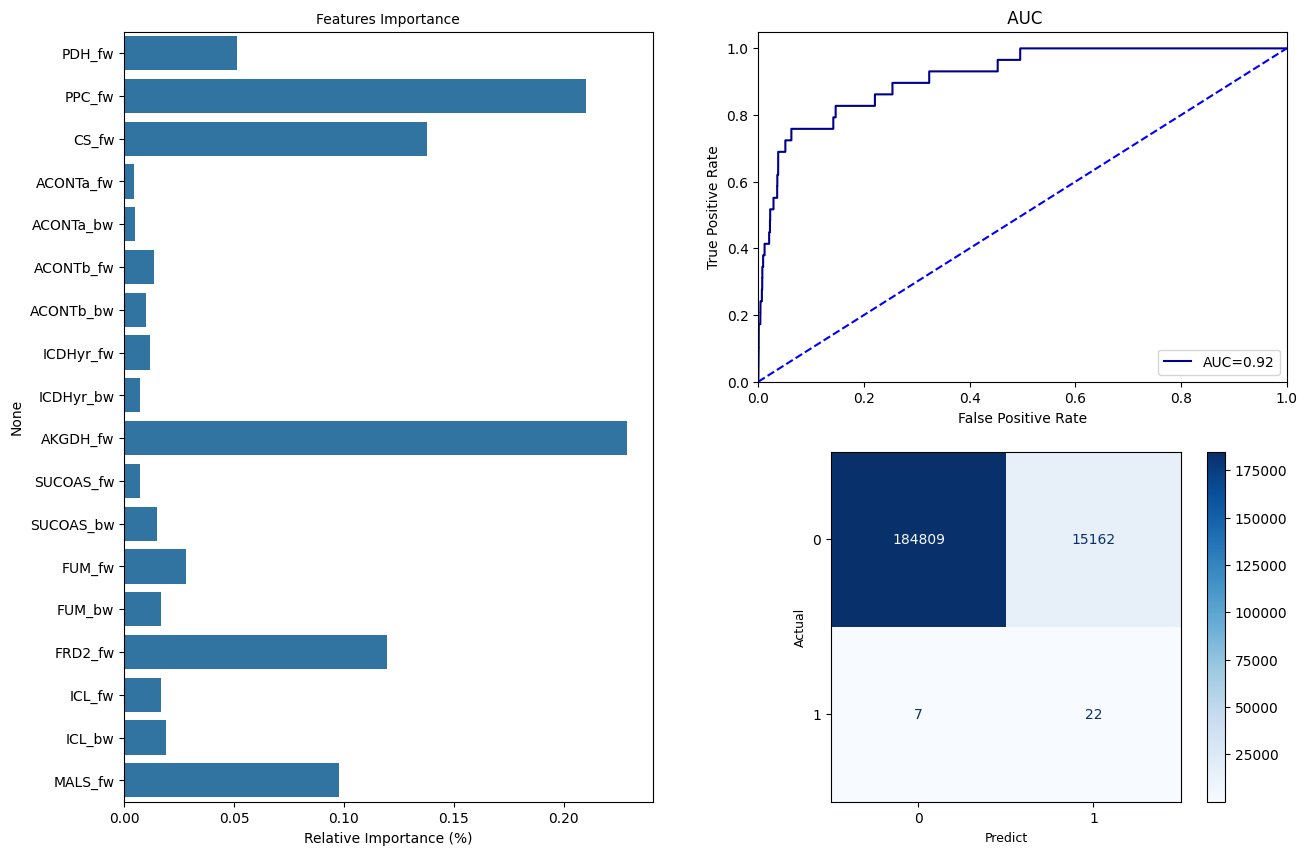

In [14]:
# Data plotting and model performance

probs = clf.predict_proba(X_test) [:,1]
y_pred = clf.predict(X_test)
        
fig = plt.figure(figsize=(15,10))
gspec = gridspec.GridSpec(2, 2)
    
# Grid configuration
top_roc_auc = fig.add_subplot(gspec[0, 1])
side_features_importances = fig.add_subplot(gspec[0:, 0])
lower_right_matrix = fig.add_subplot(gspec[1, 1])

# Features importance
sns.barplot(x = clf.feature_importances_, y = df_X.columns,ax=side_features_importances)
side_features_importances.set_title('Features Importance',fontsize=10)
side_features_importances.set_xlabel('Relative Importance (%)')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues,values_format='g',ax=lower_right_matrix)
lower_right_matrix.set_xlabel('Predict',fontsize=9)
lower_right_matrix.set_ylabel('Actual',fontsize=9)

# ROC AUC 
plot_roc(y_test,probs,top_roc_auc,'')

# Saving the image
#fig.savefig('Images/Features_importance.png',dpi=1200)

In [13]:
print(f'Recall: {recall_score(y_test, y_pred)}')
print(f'R² Model: {accuracy_score(y_test, y_pred)}')

Recall: 0.7586206896551724
R² Model: 0.924155


## 5.2.3 Final Considerations

<div style='text-align: justify'>Regarding the model performance, the AUC value is close to 1, indicating strong discriminative capability. However, as stated at the beginning of this analysis, the primary objective was to maximize recall. According to the recall_score, the model performs well in identifying true positives. This is also reflected in the confusion matrix: out of 29 combinations belonging to class 1, the model correctly predicted 22. Therefore, the feature importance values presented in the bar graph likely provide a meaningful indication of which enzymes play a more significant role in NADH and biomass production under anaerobic conditions in <i>E. coli</i> metabolism.</div><br>

<div style='text-align: justify'>With respect to the feature importance for class discrimination, 2-oxoglutarate dehydrogenase (AKGDH), phosphoenolpyruvate carboxylase (PPC) and citrate synthase (CS) shows a dominant influence on class determination, accounting for approximately 60% of the total relative importance. Additional contributions, although smaller, are observed for fumarate reductase (FRD2), pyruvate dehydrogenase (PDH) and malate synthase (MALS). These results allow a more detailed inspection of each selected enzyme to better understand their individual contributions to the observed metabolic behavior.</div><br>
<ol>
    <li><b>AKGDH:</b> Given AKGDH innate capacity to generate NADH through its reaction, it is expected that its activation could lead to overproduction of this cofactor. However, it remains unclear whether AKGDH activation itself is primarily responsible for the increase in NADH production, or if it instead promotes induction of the TCA cycle, thereby enhancing NADH generation. Thus, further analyses will be conducted to evaluate this and other questions related to NADH production under AKGDH overexpression.</li><br>
    <li><b>CS:</b> As the first enzyme of the cycle, citrate synthase, together with other strongly exergonic reactions, can limit the overall flux of the TCA cycle under specific metabolic conditions. As described by Lehninger et al., the availability of substrates for the CS reaction varies according to the metabolic state of the cell; depending on these conditions, citrate synthesis may become limited. Therefore, it is not surprising that CS exhibits such a strong influence on class determination. Because it catalyzes the entry reaction of the TCA cycle, its activity directly affects whether the cycle can proceed, which in turn impacts the level of NADH production under anaerobic conditions.</li><br>
    <li><b>PPC:</b> For PPC, it can be hypothesized that once CS is active and malate is not readily available for oxaloacetate production via malate dehydrogenase (MDH) (due to the reverse fumarase reaction) the required oxaloacetate must be supplied by an alternative pathway to sustain CS activity. In this context, PPC may contribute by generating oxaloacetate through the carboxylation of phosphoenolpyruvate. Thus, PPC could play a compensatory role in maintaining oxaloacetate availability, allowing the CS reaction to proceed. Nevertheless, additional analyses are required to confirm this hypothesis.</li><br>
    <li><b>FRD2:</b> Finally, FRD2 may play an important role in reducing fumarate levels through its conversion to succinate. This reduction in fumarate concentration could favor the reverse fumarase reaction, thereby influencing flux distribution within the pathway. However, this interpretation remains hypothetical, and additional analyses are required to clarify the underlying metabolic mechanisms.</li>
</ol>
<div style='text-align: justify'><b>Overview:</b> Considering the enzymes identified as most important, it is notable that all of them operate unidirectionally, suggesting that the directionality of these reactions may contribute to driving flux through the cycle under the analyzed conditions. This is indeed the expected behavior if TCA cycle activation is desired, since the selected enzymes regulate both the entry and the continuity of the cycle. However, given the differences in feature importance, we aim to reduce the number of modifications, focusing on one or two enzymes for NADH maximization under anaerobic conditions.</div>

<div style='text-align: justify'>With the enzymes most relevant to NADH and biomass production under anaerobic conditions now identified, the next step is to evaluate the behavior of the iCH360 model when the fluxes of these enzymes are modified.</div>

# <b>End of Part 5.2!</b>